# Active Lives London K-Modes Clustering

Purpose: create interpretable demographic clusters and export a dataset containing `Cluster`.

Clustering variables: `Age_4Band`, `Gend3`, `Eth7`, `Educ6`, `NSSEC5`, `Disab3`.

`borough` is excluded from clustering.

In [1]:
# !pip install pandas numpy matplotlib kmodes
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmodes.kmodes import KModes

RANDOM_STATE = 42
DATA_PATH = Path("active_lives_london_all_years_decoded.csv")
OUTPUT_PATH = Path("active_lives_with_clusters.csv")

## 1. Load data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Update DATA_PATH. Not found: {DATA_PATH.resolve()}")
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.drop_duplicates().copy()
print(df.shape)
display(df.head())

(135497, 610)


,serial,mode,group,Quarter,MonthTwelve,wt_final,xStrata,LA_code,LA_2023,LA_Old,...,inclus_b,inclus_c,limfreti1,limfreti2,limfreti3,limfreti4,limfreti5,limfreti6,limfreti7,limfreti8
0,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,0.727690,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.511900e+14,PAPER,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,1.120481,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.511900e+14,PAPER,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Jan to Mid-Feb,0.708328,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,1.165601,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid Nov to Mid Dec,4.191322,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Feature engineering

In [3]:
def age_band(s):
    text = s.astype(object).astype(str).str.strip().str.lower()
    label_map = {
        "16-24":"16–24","16 – 24":"16–24",
        "25-34":"25–44","25 – 34":"25–44",
        "35-44":"25–44","35 – 44":"25–44",
        "45-54":"45–64","45 – 54":"45–64",
        "55-64":"45–64","55 – 64":"45–64",
        "65-74":"65+","65 – 74":"65+",
        "75-84":"65+","75 – 84":"65+",
        "85+":"65+","85 plus":"65+"
    }
    out = text.map(label_map)
    numeric = pd.to_numeric(s, errors="coerce")
    out = out.fillna(numeric.map({
        1:"16–24",2:"25–44",3:"25–44",4:"45–64",
        5:"45–64",6:"65+",7:"65+",8:"65+"
    }))
    return out.astype(object)

if "Age_4Band" not in df.columns:
    df["Age_4Band"] = age_band(df["Age9"])

if "Activity_Level" not in df.columns:
    minutes = pd.to_numeric(df["MEMS7_ALL"], errors="coerce").mask(lambda x: x < 0)
    df["Activity_Level"] = pd.cut(
        minutes, [-0.001, 29, 149, np.inf],
        labels=["Inactive", "Fairly Active", "Active"]
    ).astype(object)

display(df["Age_4Band"].value_counts(dropna=False))
display(df["Activity_Level"].value_counts(dropna=False))

Age_4Band
25–44    53216
45–64    43555
65+      26289
16–24    11110
NaN       1327
Name: count, dtype: int64

Activity_Level
Active           90124
Inactive         30340
Fairly Active    15033
Name: count, dtype: int64

## 3. Prepare clustering data

In [4]:
cluster_features = ["Age_4Band","Gend3","Eth7","Educ6","NSSEC5","Disab3"]
missing = [x for x in cluster_features if x not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

X_cluster = df[cluster_features].copy()
for col in cluster_features:
    X_cluster[col] = (
        X_cluster[col].astype(object)
        .where(X_cluster[col].notna(), "Missing")
        .astype(str)
    )
display(X_cluster.head())

,Age_4Band,Gend3,Eth7,Educ6,NSSEC5,Disab3
0,25–44,Female,Other ethnic group,Level 4 or above,NS SEC 3-5: Middle social groups,No disability
1,Missing,Female,Black,Level 4 or above,Missing,Non-limiting disability
2,25–44,Male,South Asian,Level 4 or above,NS SEC 1-2: Higher social groups,No disability
3,45–64,Male,White British,Level 2 and equivalents,NS SEC 3-5: Middle social groups,No disability
4,45–64,Male,South Asian,Another type of qualification,NS SEC 3-5: Middle social groups,No disability


## 4. Compare k = 3, 4 and 5

Fitting k=3
Fitting k=4
Fitting k=5


,k,cost
0,3,285490.0
1,4,264745.0
2,5,257560.0


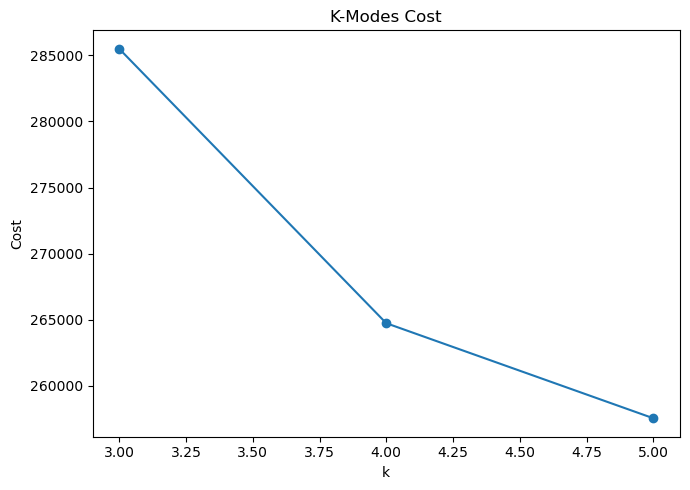

In [5]:
models, labels, costs = {}, {}, {}
for k in [3, 4, 5]:
    print(f"Fitting k={k}")
    model = KModes(
        n_clusters=k, init="Huang", n_init=5,
        random_state=RANDOM_STATE, verbose=0
    )
    labels[k] = model.fit_predict(X_cluster)
    models[k] = model
    costs[k] = model.cost_

cost_df = pd.DataFrame({"k": costs.keys(), "cost": costs.values()})
display(cost_df)
ax = cost_df.plot(x="k", y="cost", marker="o", legend=False, figsize=(7,5))
ax.set_title("K-Modes Cost")
ax.set_ylabel("Cost")
plt.tight_layout()
plt.show()

## 5. Choose final k

Review cost, cluster size and interpretability. Change `FINAL_K` if required.

In [6]:
FINAL_K = 4
df["Cluster"] = labels[FINAL_K].astype(int)
final_model = models[FINAL_K]

cluster_sizes = df["Cluster"].value_counts().sort_index().to_frame("count")
cluster_sizes["percent"] = cluster_sizes["count"] / len(df) * 100
cluster_modes = pd.DataFrame(
    final_model.cluster_centroids_,
    columns=cluster_features
)
cluster_modes.index.name = "Cluster"

display(cluster_sizes)
display(cluster_modes)

,count,percent
Cluster,,
0,51621,38.097522
1,34767,25.658871
2,35764,26.394680
3,13345,9.848927


,Age_4Band,Gend3,Eth7,Educ6,NSSEC5,Disab3
Cluster,,,,,,
0,25–44,Female,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability
1,45–64,Female,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability
2,25–44,Male,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability
3,45–64,Male,White British,Level 2 and equivalents,NS SEC 3-5: Middle social groups,No disability


## 6. Cluster profiles

In [7]:
for feature in cluster_features:
    print(f"\n{feature}")
    display((pd.crosstab(df["Cluster"], df[feature], normalize="index")*100).round(1))


Age_4Band


Age_4Band,16–24,25–44,45–64,65+
Cluster,,,,
0,12.8,61.5,0.0,25.7
1,0.0,0.0,100.0,0.0
2,9.2,60.9,0.0,29.9
3,10.1,3.5,66.2,20.2



Gend3


Gend3,Female,Male,Other
Cluster,,,
0,99.3,0.0,0.7
1,65.6,34.2,0.2
2,0.0,100.0,0.0
3,15.4,84.2,0.4



Eth7


...

Educ6,Another type of qualification,Level 1 and below,Level 2 and equivalents,Level 3 and equivalents,Level 4 or above,No qualifications
Cluster,,,,,,
0,3.8,1.4,9.1,11.7,67.6,6.4
1,3.3,1.5,6.2,10.6,74.7,3.7
2,4.0,1.4,3.6,10.6,74.2,6.3
3,6.2,2.6,55.6,11.1,14.2,10.4



NSSEC5


NSSEC5,NS SEC 1-2: Higher social groups,NS SEC 3-5: Middle social groups,NS SEC 6-8: Lower social groups,NS SEC 9: Students and other / unclassified
Cluster,,,,
0,60.4,14.7,9.9,14.9
1,74.9,11.5,9.3,4.3
2,68.9,11.4,8.1,11.6
3,5.8,66.5,14.7,13.0



Disab3


Disab3,Limiting disability,No disability,Non-limiting disability
Cluster,,,
0,15.2,70.4,14.4
1,14.8,68.1,17.2
2,11.8,73.0,15.2
3,19.6,64.7,15.7


## 7. Activity by cluster

Activity_Level,Active,Fairly Active,Inactive
Cluster,,,
0,64.2,11.8,24.0
1,70.7,10.8,18.5
2,68.4,10.2,21.4
3,59.5,11.4,29.1


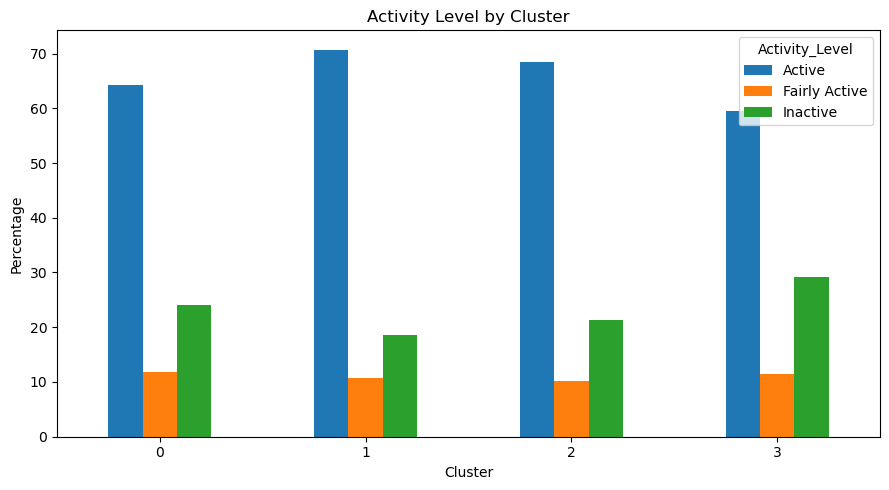

In [8]:
activity_by_cluster = (
    pd.crosstab(df["Cluster"], df["Activity_Level"], normalize="index") * 100
).round(1)
display(activity_by_cluster)
activity_by_cluster.plot(kind="bar", figsize=(9,5))
plt.ylabel("Percentage")
plt.title("Activity Level by Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Detailed cluster composition

The K-Modes centroid shows only the most common category in each cluster. To avoid over-interpreting a mode, this section reports the **full percentage distribution** of every clustering variable within every cluster.
These tables reveal that distinction and provide the evidence needed to interpret the segments responsibly.

In [9]:
# Full within-cluster percentage distributions
# Rows are categories and columns are clusters.
cluster_profile_tables = {}

for feature in cluster_features:
    table = (
        pd.crosstab(
            df[feature].fillna("Missing").astype(str),
            df["Cluster"],
            normalize="columns"
        ) * 100
    ).round(1)

    table.index.name = feature
    table.columns = [f"Cluster {int(c)}" for c in table.columns]
    cluster_profile_tables[feature] = table

    print(f"\n{feature} distribution within each cluster (%)")
    display(table)



Age_4Band distribution within each cluster (%)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Age_4Band,,,,
16–24,12.6,0.0,9.1,10.1
25–44,60.4,0.0,60.3,3.5
45–64,0.0,100.0,0.0,65.9
65+,25.2,0.0,29.6,20.1
Missing,1.8,0.0,0.9,0.5



Gend3 distribution within each cluster (%)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Gend3,,,,
Female,98.8,65.6,0.0,15.4
Male,0.0,34.1,100.0,84.1
Missing,0.5,0.1,0.0,0.2
Other,0.7,0.2,0.0,0.4



Eth7 distribution within each cluster (%)


...

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Educ6,,,,
Another type of qualification,3.6,3.1,3.7,5.7
Level 1 and below,1.3,1.4,1.3,2.4
Level 2 and equivalents,8.5,5.9,3.4,50.9
Level 3 and equivalents,11.0,10.0,9.9,10.2
Level 4 or above,63.1,70.3,69.8,13.0
Missing,6.7,5.9,6.0,8.4
No qualifications,5.9,3.5,5.9,9.5



NSSEC5 distribution within each cluster (%)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
NSSEC5,,,,
Missing,8.9,0.0,10.4,3.2
NS SEC 1-2: Higher social groups,55.1,74.9,61.7,5.6
NS SEC 3-5: Middle social groups,13.4,11.5,10.2,64.4
NS SEC 6-8: Lower social groups,9.0,9.3,7.3,14.2
NS SEC 9: Students and other / unclassified,13.6,4.3,10.4,12.6



Disab3 distribution within each cluster (%)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Disab3,,,,
Limiting disability,14.0,14.0,11.1,18.2
Missing,7.7,5.6,6.2,7.2
No disability,65.0,64.2,68.4,60.0
Non-limiting disability,13.3,16.2,14.3,14.5


## 9. Integrated clustering summary

This summary combines cluster size, each modal category, and the percentage of respondents represented by that mode. The mode percentage indicates how strongly the category characterises the cluster.

In [10]:
def mode_and_percentage(series):
    """Return the dominant non-missing category and its within-series percentage."""
    clean = series.fillna("Missing").astype(str)
    counts = clean.value_counts(dropna=False)
    if counts.empty:
        return pd.Series({"mode": np.nan, "mode_percent": np.nan})
    dominant = counts.index[0]
    percentage = counts.iloc[0] / counts.sum() * 100
    return pd.Series({"mode": dominant, "mode_percent": round(percentage, 1)})

summary_rows = []

for cluster_id, group in df.groupby("Cluster", sort=True):
    row = {
        "Cluster": int(cluster_id),
        "Respondents": len(group),
        "Cluster Size (%)": round(len(group) / len(df) * 100, 1)
    }

    for feature in cluster_features:
        result = mode_and_percentage(group[feature])
        row[f"{feature} — Mode"] = result["mode"]
        row[f"{feature} — Mode (%)"] = result["mode_percent"]

    summary_rows.append(row)

cluster_composition_summary = pd.DataFrame(summary_rows).sort_values("Cluster")

display(cluster_composition_summary)


,Cluster,Respondents,Cluster Size (%),Age_4Band — Mode,Age_4Band — Mode (%),Gend3 — Mode,Gend3 — Mode (%),Eth7 — Mode,Eth7 — Mode (%),Educ6 — Mode,Educ6 — Mode (%),NSSEC5 — Mode,NSSEC5 — Mode (%),Disab3 — Mode,Disab3 — Mode (%)
0,0,51621,38.1,25–44,60.4,Female,98.8,White British,46.3,Level 4 or above,63.1,NS SEC 1-2: Higher social groups,55.1,No disability,65.0
1,1,34767,25.7,45–64,100.0,Female,65.6,White British,55.6,Level 4 or above,70.3,NS SEC 1-2: Higher social groups,74.9,No disability,64.2
2,2,35764,26.4,25–44,60.3,Male,100.0,White British,50.4,Level 4 or above,69.8,NS SEC 1-2: Higher social groups,61.7,No disability,68.4
3,3,13345,9.8,45–64,65.9,Male,84.1,White British,57.3,Level 2 and equivalents,50.9,NS SEC 3-5: Middle social groups,64.4,No disability,60.0


## 10. Export outputs

The clustered respondent-level dataset remains in the notebook directory so Prediction Notebook can load it directly. Supporting clustering outputs are saved in `clustering_outputs`.

In [11]:
OUTPUT_DIR = Path("clustering_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main hand-off file used by Notebook 2
df.to_csv(OUTPUT_PATH, index=False)

# Core clustering outputs
cluster_modes.to_csv(OUTPUT_DIR / "cluster_modes.csv")
cluster_sizes.to_csv(OUTPUT_DIR / "cluster_sizes.csv")
activity_by_cluster.to_csv(OUTPUT_DIR / "activity_by_cluster.csv")
cluster_composition_summary.to_csv(
    OUTPUT_DIR / "cluster_composition_summary.csv",
    index=False
)

# One full percentage-distribution table per clustering variable
for feature, table in cluster_profile_tables.items():
    safe_name = feature.lower().replace(" ", "_")
    table.to_csv(OUTPUT_DIR / f"cluster_distribution_{safe_name}.csv")

# Long-form version containing all distributions in one file
long_profiles = []
for feature, table in cluster_profile_tables.items():
    temp = table.reset_index().melt(
        id_vars=feature,
        var_name="Cluster",
        value_name="Percentage"
    )
    temp = temp.rename(columns={feature: "Category"})
    temp.insert(0, "Feature", feature)
    long_profiles.append(temp)

cluster_profile_distributions_long = pd.concat(long_profiles, ignore_index=True)
cluster_profile_distributions_long.to_csv(
    OUTPUT_DIR / "cluster_profile_distributions_long.csv",
    index=False
)

print(f"Saved clustered data for Notebook 2: {OUTPUT_PATH.resolve()}")
print(f"Saved clustering summaries to: {OUTPUT_DIR.resolve()}")
print("\nKey outputs:")
print("- active_lives_with_clusters.csv")
print("- clustering_outputs/cluster_composition_summary.csv")
print("- clustering_outputs/cluster_profile_distributions_long.csv")
print("- clustering_outputs/cluster_distribution_<feature>.csv")


Saved clustered data for Notebook 2: /Users/sanyakapoor/Downloads/FINAL NOTEBOOK/active_lives_with_clusters.csv
Saved clustering summaries to: /Users/sanyakapoor/Downloads/FINAL NOTEBOOK/clustering_outputs

Key outputs:
- active_lives_with_clusters.csv
- clustering_outputs/cluster_composition_summary.csv
- clustering_outputs/cluster_profile_distributions_long.csv
- clustering_outputs/cluster_distribution_<feature>.csv
